In [3]:
# CIFAR-100 optimizer benchmark
# Run this notebook in Google Colab with a GPU runtime.
# AdamN is installed from the wheel published in the GitHub repo.

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.optim import Optimizer
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import gc
import math
import random

!pip install "https://github.com/maboulsaad82/AdmaN/raw/main/adamn_optimizer-0.1.0-cp312-cp312-linux_x86_64.whl"

try:
    from adamn.optimizer import AdamN
except ImportError as exc:
    raise ImportError(
        "AdamN is not installed. Run the wheel-install cell before importing this code."
    ) from exc

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Main knobs for the run
USE_AMP = True                    # Use AMP for every optimizer in the comparison.
ACCUMULATE_STEPS = 1
USE_CHANNELS_LAST = True
EVAL_TEST_EACH_EPOCH = False


# ==============================================================================
# Optimizers used in the comparison
# ==============================================================================


def _mode_matmul(x: torch.Tensor, mat: torch.Tensor, mode: int) -> torch.Tensor:
    x = x.movedim(mode, 0)
    orig_shape = x.shape
    x2 = x.reshape(orig_shape[0], -1)
    y2 = mat @ x2
    y = y2.reshape((mat.shape[0],) + orig_shape[1:])
    return y.movedim(0, mode)


def _tensor_to_eigenbasis(x: torch.Tensor, eigvecs):
    y = x
    for mode, q in enumerate(eigvecs):
        y = _mode_matmul(y, q.transpose(0, 1), mode)
    return y


def _tensor_from_eigenbasis(x: torch.Tensor, eigvecs):
    y = x
    for mode, q in enumerate(eigvecs):
        y = _mode_matmul(y, q, mode)
    return y


def _unfold(x: torch.Tensor, mode: int) -> torch.Tensor:
    return x.movedim(mode, 0).reshape(x.shape[mode], -1)


@torch.no_grad()
def _matrix_inverse_root(mat: torch.Tensor, power: float, eps: float) -> torch.Tensor:
    mat32 = mat.float()
    eye = torch.eye(mat32.shape[0], device=mat32.device, dtype=mat32.dtype)
    evals, evecs = torch.linalg.eigh(mat32 + eps * eye)
    evals.clamp_(min=eps)
    inv_root = evecs @ torch.diag(evals.pow(power)) @ evecs.transpose(0, 1)
    return inv_root.to(dtype=mat.dtype)


@torch.no_grad()
def _matrix_eigh(mat: torch.Tensor, eps: float) -> torch.Tensor:
    mat32 = mat.float()
    eye = torch.eye(mat32.shape[0], device=mat32.device, dtype=mat32.dtype)
    _, evecs = torch.linalg.eigh(mat32 + eps * eye)
    return evecs.to(dtype=mat.dtype)


class Shampoo(Optimizer):
    """
    Compact Shampoo implementation for this benchmark.
    - nD Shampoo-style preconditioning for tensors with ndim >= 2
    - SGD/momentum fallback for 1D tensors
    - decoupled weight decay
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        momentum=0.9,
        weight_decay=0.0,
        epsilon=1e-8,
        update_freq=10,
    ):
        defaults = dict(
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
            epsilon=epsilon,
            update_freq=update_freq,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]
            wd = group["weight_decay"]
            eps = group["epsilon"]
            update_freq = group["update_freq"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                if grad.is_sparse:
                    raise RuntimeError("Shampoo does not support sparse gradients.")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    if p.ndim >= 2:
                        state["preconds"] = [
                            torch.zeros((d, d), device=p.device, dtype=torch.float32)
                            for d in p.shape
                        ]
                        state["inv_preconds"] = [
                            torch.eye(d, device=p.device, dtype=p.dtype) for d in p.shape
                        ]
                    if momentum > 0:
                        state["momentum_buffer"] = torch.zeros_like(p)

                state["step"] += 1

                if wd != 0:
                    p.mul_(1 - lr * wd)

                if p.ndim < 2:
                    update = grad
                    if momentum > 0:
                        buf = state["momentum_buffer"]
                        buf.mul_(momentum).add_(grad)
                        update = buf
                    p.add_(update, alpha=-lr)
                    continue

                preconds = state["preconds"]
                for mode in range(p.ndim):
                    g_mode = _unfold(grad, mode).float()
                    preconds[mode].add_(g_mode @ g_mode.transpose(0, 1))

                if state["step"] % update_freq == 0:
                    power = -1.0 / (2.0 * p.ndim)
                    state["inv_preconds"] = [
                        _matrix_inverse_root(mat, power, eps) for mat in preconds
                    ]

                update = grad
                for mode, inv_p in enumerate(state["inv_preconds"]):
                    update = _mode_matmul(update, inv_p, mode)

                if momentum > 0:
                    buf = state["momentum_buffer"]
                    buf.mul_(momentum).add_(update)
                    update = buf

                p.add_(update, alpha=-lr)

        return loss


class SophiaG(Optimizer):
    """
    Practical drop-in Sophia-style optimizer for standard training loops.

    Note:
    - Official Sophia-G usually updates a Hessian estimator separately.
    - This class keeps the same clipped preconditioned-update spirit but uses
      an EMA of grad^2 as an in-loop curvature proxy so it works with a plain
      loss.backward(); optimizer.step() loop.
    """

    def __init__(
        self,
        params,
        lr=1e-4,
        betas=(0.965, 0.99),
        rho=0.04,
        weight_decay=0.0,
        eps=1e-8,
    ):
        if len(betas) != 2:
            raise ValueError("SophiaG expects betas=(beta1, beta2).")
        defaults = dict(
            lr=lr,
            betas=betas,
            rho=rho,
            weight_decay=weight_decay,
            eps=eps,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None, bs=1):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            rho = group["rho"]
            wd = group["weight_decay"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                if grad.is_sparse:
                    raise RuntimeError("SophiaG does not support sparse gradients.")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["hessian"] = torch.zeros_like(p)

                state["step"] += 1
                exp_avg = state["exp_avg"]
                hessian = state["hessian"]

                if wd != 0:
                    p.mul_(1 - lr * wd)

                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)

                # Curvature proxy used in this plain training loop.
                hessian.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                update = exp_avg / (rho * hessian + eps)
                update.clamp_(min=-1.0, max=1.0)

                p.add_(update, alpha=-lr)

        return loss


class AdEMAMix(Optimizer):
    """
    AdEMAMix as a drop-in optimizer.

    Official paper code uses:
        update = (m1 / (1 - beta1^t) + alpha_t * m2) / denom
    with beta3 and alpha optionally warmed up.
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999, 0.9999),
        alpha=5.0,
        beta3_warmup=0,
        alpha_warmup=0,
        weight_decay=0.0,
        eps=1e-8,
    ):
        if len(betas) != 3:
            raise ValueError("AdEMAMix expects betas=(beta1, beta2, beta3).")
        defaults = dict(
            lr=lr,
            betas=betas,
            alpha=alpha,
            beta3_warmup=beta3_warmup,
            alpha_warmup=alpha_warmup,
            weight_decay=weight_decay,
            eps=eps,
        )
        super().__init__(params, defaults)

    @staticmethod
    def _linear_warmup(step: int, start: float, end: float, warmup: int) -> float:
        if warmup is None or warmup <= 0:
            return end
        if step >= warmup:
            return end
        return start + (end - start) * (step / float(warmup))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2, beta3_final = group["betas"]
            alpha_final = group["alpha"]
            beta3_warmup = group["beta3_warmup"]
            alpha_warmup = group["alpha_warmup"]
            wd = group["weight_decay"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                if grad.is_sparse:
                    raise RuntimeError("AdEMAMix does not support sparse gradients.")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    if beta1 != 0:
                        state["m1"] = torch.zeros_like(p)
                    state["m2"] = torch.zeros_like(p)
                    state["nu"] = torch.zeros_like(p)

                state["step"] += 1
                step = state["step"]

                beta3_t = self._linear_warmup(step, beta1, beta3_final, beta3_warmup)
                alpha_t = self._linear_warmup(step, 0.0, alpha_final, alpha_warmup)

                if wd != 0:
                    p.mul_(1 - lr * wd)

                if beta1 != 0:
                    m1 = state["m1"]
                    m1.mul_(beta1).add_(grad, alpha=1 - beta1)
                    fast = m1 / (1 - beta1 ** step)
                else:
                    fast = grad

                m2 = state["m2"]
                nu = state["nu"]

                m2.mul_(beta3_t).add_(grad, alpha=1 - beta3_t)
                nu.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                bias_correction2 = 1 - beta2 ** step
                denom = nu.sqrt().div(math.sqrt(bias_correction2)).add_(eps)

                update = (fast + alpha_t * m2) / denom
                p.add_(update, alpha=-lr)

        return loss


class SOAP(Optimizer):
    """
    Compact SOAP implementation used in this benchmark:
    - Shampoo-style preconditioner statistics
    - Adam update performed in the preconditioner eigenbasis
    - AdamW fallback on 1D tensors
    """

    def __init__(
        self,
        params,
        lr=3e-4,
        betas=(0.95, 0.95),
        weight_decay=0.0,
        eps=1e-8,
        precondition_frequency=10,
    ):
        if len(betas) != 2:
            raise ValueError("SOAP expects betas=(beta1, beta2).")
        defaults = dict(
            lr=lr,
            betas=betas,
            weight_decay=weight_decay,
            eps=eps,
            precondition_frequency=precondition_frequency,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            wd = group["weight_decay"]
            eps = group["eps"]
            freq = group["precondition_frequency"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                if grad.is_sparse:
                    raise RuntimeError("SOAP does not support sparse gradients.")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                    if p.ndim >= 2:
                        state["preconds"] = [
                            torch.zeros((d, d), device=p.device, dtype=torch.float32)
                            for d in p.shape
                        ]
                        state["eigvecs"] = [
                            torch.eye(d, device=p.device, dtype=p.dtype) for d in p.shape
                        ]

                state["step"] += 1
                step = state["step"]

                if wd != 0:
                    p.mul_(1 - lr * wd)

                if p.ndim < 2:
                    exp_avg = state["exp_avg"]
                    exp_avg_sq = state["exp_avg_sq"]
                    exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                    exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                    bc1 = 1 - beta1 ** step
                    bc2 = 1 - beta2 ** step
                    denom = exp_avg_sq.sqrt().div(math.sqrt(bc2)).add_(eps)
                    update = exp_avg.div(bc1).div(denom)
                    p.add_(update, alpha=-lr)
                    continue

                preconds = state["preconds"]
                for mode in range(p.ndim):
                    g_mode = _unfold(grad, mode).float()
                    preconds[mode].add_(g_mode @ g_mode.transpose(0, 1))

                if step % freq == 0:
                    state["eigvecs"] = [_matrix_eigh(mat, eps) for mat in preconds]

                eigvecs = state["eigvecs"]
                grad_basis = _tensor_to_eigenbasis(grad, eigvecs)

                exp_avg = state["exp_avg"]
                exp_avg_sq = state["exp_avg_sq"]
                exp_avg.mul_(beta1).add_(grad_basis, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad_basis, grad_basis, value=1 - beta2)

                bc1 = 1 - beta1 ** step
                bc2 = 1 - beta2 ** step
                denom = exp_avg_sq.sqrt().div(math.sqrt(bc2)).add_(eps)
                update_basis = exp_avg.div(bc1).div(denom)
                update = _tensor_from_eigenbasis(update_basis, eigvecs)

                p.add_(update, alpha=-lr)

        return loss


class MARS(Optimizer):
    """
    MARS-AdamW-style drop-in optimizer.

    Official MARS keeps the previous gradient and may expose an update_last_grad()
    call in the training loop. This implementation stores the previous gradient
    internally so it works as a plain optimizer.step() replacement.
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.95, 0.99),
        gamma=0.025,
        weight_decay=0.0,
        eps=1e-8,
    ):
        if len(betas) != 2:
            raise ValueError("MARS expects betas=(beta1, beta2).")
        defaults = dict(
            lr=lr,
            betas=betas,
            gamma=gamma,
            weight_decay=weight_decay,
            eps=eps,
        )
        super().__init__(params, defaults)

    def update_last_grad(self):
        # Kept only for API compatibility with the official repo.
        return None

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            gamma = group["gamma"]
            wd = group["weight_decay"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                if grad.is_sparse:
                    raise RuntimeError("MARS does not support sparse gradients.")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["last_grad"] = torch.zeros_like(p)
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)

                state["step"] += 1
                step = state["step"]
                last_grad = state["last_grad"]
                exp_avg = state["exp_avg"]
                exp_avg_sq = state["exp_avg_sq"]

                if wd != 0:
                    p.mul_(1 - lr * wd)

                if step == 1:
                    c_t = grad
                else:
                    correction = gamma * (beta1 / max(1e-12, (1 - beta1))) * (grad - last_grad)
                    c_t = grad + correction

                c_norm = torch.norm(c_t)
                if torch.isfinite(c_norm) and c_norm > 1.0:
                    c_t = c_t / c_norm

                exp_avg.mul_(beta1).add_(c_t, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                bc1 = 1 - beta1 ** step
                bc2 = 1 - beta2 ** step
                denom = exp_avg_sq.sqrt().div(math.sqrt(bc2)).add_(eps)
                update = exp_avg.div(bc1).div(denom)

                p.add_(update, alpha=-lr)
                last_grad.copy_(grad)

        return loss

class Lion(Optimizer):
    r"""
    Lion optimizer (Google Research, 2023)
    Reference: https://arxiv.org/abs/2302.06675

    Key properties:
    - Uses sign of momentum-interpolated gradient for updates
    - Only tracks momentum (no second moment) - memory efficient
    - Requires 3-10x smaller LR than Adam, 3-10x larger weight decay

    Args:
        params: Parameters to optimize
        lr: Learning rate (default: 1e-4, typically 3-10x smaller than Adam)
        betas: (beta1, beta2) for update interpolation and momentum tracking
        weight_decay: Decoupled weight decay coefficient
    """
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta[0]: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta[1]: {betas[1]}")
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError('Lion does not support sparse gradients')

                state = self.state[p]
                if len(state) == 0:
                    state['exp_avg'] = torch.zeros_like(p)
                    state['step'] = 0

                exp_avg = state['exp_avg']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # Decoupled weight decay
                if group['weight_decay'] != 0:
                    p.mul_(1 - group['lr'] * group['weight_decay'])

                # Compute update direction: interpolate momentum and gradient, then sign
                update = exp_avg * beta1 + grad * (1 - beta1)
                p.add_(torch.sign(update), alpha=-group['lr'])

                # Update momentum (different beta for tracking)
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)

        return loss


class Adan(Optimizer):
    r"""
    Adan optimizer (Adaptive Nesterov Momentum, 2022)
    Reference: https://arxiv.org/abs/2208.06677

    Key properties:
    - Uses Nesterov-style gradient difference term
    - Three beta parameters for different moment estimates
    - Can use up to 5-10x larger LR than AdamW

    Args:
        params: Parameters to optimize
        lr: Learning rate (default: 1e-3)
        betas: (beta1, beta2, beta3) for moment estimates
        eps: Numerical stability term
        weight_decay: Weight decay coefficient (default: 0.02)
        no_prox: If True, use AdamW-style weight decay
    """
    def __init__(self, params, lr=1e-3, betas=(0.98, 0.92, 0.99), eps=1e-8,
                 weight_decay=0.02, no_prox=False):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon: {eps}")
        for i, b in enumerate(betas):
            if not 0.0 <= b < 1.0:
                raise ValueError(f"Invalid beta[{i}]: {b}")
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay, no_prox=no_prox)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            beta1, beta2, beta3 = group['betas']
            eps = group['eps']
            lr = group['lr']
            wd = group['weight_decay']
            no_prox = group['no_prox']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError('Adan does not support sparse gradients')

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)       # m_t
                    state['exp_avg_diff'] = torch.zeros_like(p)  # v_t
                    state['exp_avg_sq'] = torch.zeros_like(p)    # n_t
                    state['prev_grad'] = torch.zeros_like(p)     # g_{t-1}

                exp_avg = state['exp_avg']
                exp_avg_diff = state['exp_avg_diff']
                exp_avg_sq = state['exp_avg_sq']
                prev_grad = state['prev_grad']

                state['step'] += 1
                t = state['step']

                # Gradient difference
                diff = grad - prev_grad

                # Update moments
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_diff.mul_(beta2).add_(diff, alpha=1 - beta2)

                update_term = grad + beta2 * diff
                exp_avg_sq.mul_(beta3).addcmul_(update_term, update_term, value=1 - beta3)

                # Bias correction
                bc1 = 1 - beta1 ** t
                bc2 = 1 - beta2 ** t
                bc3 = 1 - beta3 ** t

                m_hat = exp_avg / bc1
                v_hat = exp_avg_diff / bc2
                n_hat = exp_avg_sq / bc3

                denom = n_hat.sqrt().add_(eps)

                # Update with weight decay
                if no_prox:
                    p.mul_(1 - lr * wd)
                    p.addcdiv_(m_hat + beta2 * v_hat, denom, value=-lr)
                else:
                    p.addcdiv_(m_hat + beta2 * v_hat, denom, value=-lr)
                    p.div_(1 + lr * wd)

                prev_grad.copy_(grad)

        return loss


class AdaBelief(Optimizer):
    r"""
    AdaBelief optimizer (NeurIPS 2020 Spotlight)
    Reference: https://arxiv.org/abs/2010.07468

    Key properties:
    - Adapts stepsize based on "belief" in gradient direction
    - Tracks EMA of (g - m)^2 instead of g^2
    - Takes large steps when gradient matches prediction, small when deviating

    Args:
        params: Parameters to optimize
        lr: Learning rate (default: 1e-3)
        betas: (beta1, beta2) for moment estimates
        eps: Numerical stability (default: 1e-16 for Transformers, 1e-8 for CNNs)
        weight_decay: Weight decay coefficient
        weight_decouple: Use decoupled weight decay like AdamW
        rectify: Use RAdam-style variance rectification
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0, weight_decouple=True, rectify=False, amsgrad=False):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta[0]: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta[1]: {betas[1]}")

        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        weight_decouple=weight_decouple, rectify=rectify, amsgrad=amsgrad)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError('AdaBelief does not support sparse gradients')

                amsgrad = group['amsgrad']
                state = self.state[p]
                beta1, beta2 = group['betas']

                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_var'] = torch.zeros_like(p)
                    if amsgrad:
                        state['max_exp_avg_var'] = torch.zeros_like(p)

                exp_avg = state['exp_avg']
                exp_avg_var = state['exp_avg_var']
                state['step'] += 1
                t = state['step']

                bc1 = 1 - beta1 ** t
                bc2 = 1 - beta2 ** t

                # Weight decay
                if group['weight_decouple']:
                    if group['weight_decay'] != 0:
                        p.mul_(1 - group['lr'] * group['weight_decay'])
                else:
                    if group['weight_decay'] != 0:
                        grad = grad.add(p, alpha=group['weight_decay'])

                # Update first moment
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)

                # Update second moment (belief: deviation from prediction)
                grad_residual = grad - exp_avg
                exp_avg_var.mul_(beta2).addcmul_(grad_residual, grad_residual, value=1 - beta2)

                if amsgrad:
                    max_exp_avg_var = state['max_exp_avg_var']
                    torch.max(max_exp_avg_var, exp_avg_var, out=max_exp_avg_var)
                    denom = (max_exp_avg_var.add_(group['eps']).sqrt() /
                             math.sqrt(bc2)).add_(group['eps'])
                else:
                    denom = (exp_avg_var.add_(group['eps']).sqrt() /
                             math.sqrt(bc2)).add_(group['eps'])

                # Compute step
                if group['rectify']:
                    rho_inf = 2.0 / (1 - beta2) - 1.0
                    rho_t = rho_inf - 2.0 * t * (beta2 ** t) / bc2

                    if rho_t > 5:
                        rect = math.sqrt(
                            (rho_t - 4) * (rho_t - 2) * rho_inf /
                            ((rho_inf - 4) * (rho_inf - 2) * rho_t)
                        )
                        step_size = group['lr'] * rect / bc1
                        p.addcdiv_(exp_avg, denom, value=-step_size)
                    else:
                        step_size = group['lr'] / bc1
                        p.add_(exp_avg, alpha=-step_size)
                else:
                    step_size = group['lr'] / bc1
                    p.addcdiv_(exp_avg, denom, value=-step_size)

        return loss



# AdamN is installed from the wheel above, so its source code is not included here.


class MuonWithAuxAdamW(Optimizer):
    """
    Hybrid optimizer:
      - Muon update for 2D parameters (matrices)
      - AdamW update for all other parameters (1D/3D/4D, embeddings, tokens, norms, convs, biases)

    Works with PyTorch schedulers because it is an Optimizer and exposes param_groups.
    """
    def __init__(self, param_groups):
        # param_groups: list of dicts, each dict MUST include 'use_muon': True/False
        for g in param_groups:
            if "use_muon" not in g:
                raise ValueError("Each param_group must include use_muon=True/False")

            if g["use_muon"]:
                g.setdefault("lr", 1e-3)
                g.setdefault("weight_decay", 0.0)
                g.setdefault("momentum", 0.95)
                g.setdefault("nesterov", True)
                g.setdefault("ns_steps", 5)
                # if your torch has ns_coefficients/eps, you can add them, but defaults are fine

            else:
                g.setdefault("lr", 1e-3)
                g.setdefault("weight_decay", 0.0)
                g.setdefault("betas", (0.9, 0.999))
                g.setdefault("eps", 1e-8)

        super().__init__(param_groups, defaults={})

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            if group["use_muon"]:
                # Muon for 2D params only
                muon = torch.optim.Muon(
                    [group],  # lightweight Muon view over this single group
                    lr=group["lr"],
                    weight_decay=group["weight_decay"],
                    momentum=group["momentum"],
                    nesterov=group["nesterov"],
                    ns_steps=group["ns_steps"],
                )
                # Share state dict with this wrapper
                muon.state = self.state
                muon.step()

            else:
                # AdamW for non-2D params
                adamw = torch.optim.AdamW(
                    [group],
                    lr=group["lr"],
                    betas=group["betas"],
                    eps=group["eps"],
                    weight_decay=group["weight_decay"],
                )
                adamw.state = self.state
                adamw.step()

        return loss


def split_named_params_for_muon(named_params):
    """
    Return two lists:
      - muon_named: (name,param) where param.ndim == 2
      - aux_named : everything else (1D/3D/4D)
    """
    muon_named, aux_named = [], []
    for n, p in named_params:
        if not p.requires_grad:
            continue
        if p.ndim == 2:
            muon_named.append((n, p))
        else:
            aux_named.append((n, p))
    return muon_named, aux_named

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cleanup_cuda(verbose=False):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        if verbose:
            print(torch.cuda.memory_summary(abbreviated=True))




# ==============================================================================
# INSTANTANEOUS LR METRICS FOR ALL OPTIMIZERS
# ==============================================================================

def _int_step(step_val):
    if torch.is_tensor(step_val):
        return int(step_val.item())
    return int(step_val) if step_val else 0


def compute_adamw_instlr_metrics(opt):
    """Compute instantaneous LR metrics for Adam/AdamW."""
    group = opt.param_groups[0]
    lr, eps = group['lr'], group.get('eps', 1e-8)
    b1, b2 = group['betas']

    sum_mult, sum_step_sq, count = 0.0, 0.0, 0
    for p, st in opt.state.items():
        if 'exp_avg' not in st or 'exp_avg_sq' not in st:
            continue
        t = _int_step(st.get('step', 0))
        if t <= 0:
            continue
        m, v = st['exp_avg'], st['exp_avg_sq']
        m_hat = m / (1.0 - b1**t)
        v_hat = v / (1.0 - b2**t)
        denom = torch.sqrt(v_hat).add(eps)
        num_factor = (1.0 - b1) / (1.0 - b1**t)
        sum_mult += (num_factor / denom).detach().float().sum().item()
        sum_step_sq += (lr * m_hat / denom).detach().float().pow(2).sum().item()
        count += denom.numel()

    if count == 0:
        return {"base_lr": lr, "multiplier": 0.0, "inst_lr": 0.0, "step_rms": 0.0}
    mult = sum_mult / count
    return {"base_lr": lr, "multiplier": mult, "inst_lr": lr * mult,
            "step_rms": math.sqrt(sum_step_sq / count)}


def compute_lion_instlr_metrics(opt):
    """Compute metrics for Lion (step magnitude is constant = lr)."""
    group = opt.param_groups[0]
    lr = group['lr']
    count = sum(st['exp_avg'].numel() for st in opt.state.values() if 'exp_avg' in st)
    if count == 0:
        return {"base_lr": lr, "multiplier": 1.0, "inst_lr": lr, "step_rms": 0.0}
    return {"base_lr": lr, "multiplier": 1.0, "inst_lr": lr, "step_rms": lr}


def compute_adan_instlr_metrics(opt):
    """Compute instantaneous LR metrics for Adan."""
    group = opt.param_groups[0]
    lr, eps = group['lr'], group.get('eps', 1e-8)
    b1, b2, b3 = group['betas']

    sum_mult, sum_step_sq, count = 0.0, 0.0, 0
    for p, st in opt.state.items():
        if 'exp_avg' not in st or 'exp_avg_sq' not in st:
            continue
        t = _int_step(st.get('step', 0))
        if t <= 0:
            continue
        m, v, n = st['exp_avg'], st.get('exp_avg_diff', torch.zeros_like(st['exp_avg'])), st['exp_avg_sq']
        bc1, bc2, bc3 = 1-b1**t, 1-b2**t, 1-b3**t
        m_hat, v_hat, n_hat = m/bc1, v/bc2, n/bc3
        denom = torch.sqrt(n_hat).add(eps)
        update = m_hat + b2 * v_hat
        sum_mult += (1.0 / denom).detach().float().sum().item()
        sum_step_sq += (lr * update / denom).detach().float().pow(2).sum().item()
        count += denom.numel()

    if count == 0:
        return {"base_lr": lr, "multiplier": 0.0, "inst_lr": 0.0, "step_rms": 0.0}
    mult = sum_mult / count
    return {"base_lr": lr, "multiplier": mult, "inst_lr": lr * mult,
            "step_rms": math.sqrt(sum_step_sq / count)}


def compute_adabelief_instlr_metrics(opt):
    """Compute instantaneous LR metrics for AdaBelief."""
    group = opt.param_groups[0]
    lr, eps = group['lr'], group.get('eps', 1e-16)
    b1, b2 = group['betas']

    sum_mult, sum_step_sq, count = 0.0, 0.0, 0
    for p, st in opt.state.items():
        if 'exp_avg' not in st or 'exp_avg_var' not in st:
            continue
        t = _int_step(st.get('step', 0))
        if t <= 0:
            continue
        m, s = st['exp_avg'], st['exp_avg_var']
        bc1, bc2 = 1-b1**t, 1-b2**t
        denom = (s.add(eps).sqrt() / math.sqrt(bc2)).add(eps)
        m_hat = m / bc1
        sum_mult += ((1.0-b1)/(bc1*denom)).detach().float().sum().item()
        sum_step_sq += (lr * m_hat / denom / bc1).detach().float().pow(2).sum().item()
        count += denom.numel()

    if count == 0:
        return {"base_lr": lr, "multiplier": 0.0, "inst_lr": 0.0, "step_rms": 0.0}
    mult = sum_mult / count
    return {"base_lr": lr, "multiplier": mult, "inst_lr": lr * mult,
            "step_rms": math.sqrt(sum_step_sq / count)}


def compute_adamn_instlr_metrics(opt, mode='exact'):
    """Compute instantaneous LR metrics for AdamN."""
    group = opt.param_groups[0]
    lr, eps = group['lr'], group.get('eps', 1e-8)
    b1, b2, b3 = group['betas']

    sum_mult, sum_step_sq, count = 0.0, 0.0, 0
    for p, st in opt.state.items():
        if 'a_t' not in st or 's_t' not in st:
            continue
        t = _int_step(st.get('step', 0))
        if t <= 0:
            continue
        a_t, s_t = st['a_t'], st['s_t']
        if mode == 'exact':
            f_t = max(_nested_bias_correction_factor(t, b1, b2), 1e-16)
        else:
            f_t = max(1.0 - b2**t, 1e-16)
        s_hat = s_t / (1.0 - b3**t)
        denom = torch.sqrt(s_hat).add(eps)
        num_factor = (1.0-b1)*(1.0-b2)/f_t
        a_hat = a_t / f_t
        sum_mult += (num_factor / denom).detach().float().sum().item()
        sum_step_sq += (lr * a_hat / denom).detach().float().pow(2).sum().item()
        count += denom.numel()

    if count == 0:
        return {"base_lr": lr, "multiplier": 0.0, "inst_lr": 0.0, "step_rms": 0.0}
    mult = sum_mult / count
    return {"base_lr": lr, "multiplier": mult, "inst_lr": lr * mult,
            "step_rms": math.sqrt(sum_step_sq / count)}


# ==============================================================================
# MODEL FACTORY
# ==============================================================================

def resnet18_cifar100(num_classes=100):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# CIFAR-friendly ViT used for small-image experiments
# This version learns from scratch under the same training loop.
# A light conv stem adds locality, and Pre-LN keeps training stable.

class CIFARViT(nn.Module):
    def __init__(
        self,
        num_classes=100,
        img_size=32,
        patch_size=4,          # 32/4 -> 8x8 = 64 tokens
        embed_dim=256,
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        attn_dropout=0.0,
        drop=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim

        # Small conv stem for local image structure.
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.GELU(),
            nn.Conv2d(64, embed_dim, kernel_size=3, stride=1, padding=1, bias=True),
            nn.GELU(),
        )

        # Convert the stem output into patch tokens.
        self.patch_embed = nn.Conv2d(embed_dim, embed_dim, kernel_size=patch_size, stride=patch_size, bias=True)

        # CLS token and learned positional embeddings.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        self.pos_drop  = nn.Dropout(drop)

        # Pre-LN Transformer encoder.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=drop,
            activation="gelu",
            batch_first=True,        # (B, N, D)
            norm_first=True          # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes, bias=True)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.xavier_uniform_(self.head.weight)
        if self.head.bias is not None:
            nn.init.zeros_(self.head.bias)
        # Kaiming init for convs helps early signal
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear) and m is not self.head:
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):                     # x: [B,3,32,32]
        B = x.size(0)
        x = self.stem(x)                      # [B, D, 32, 32]
        x = self.patch_embed(x)               # [B, D, 8, 8]
        x = x.flatten(2).transpose(1, 2)      # [B, 64, D]
        cls = self.cls_token.expand(B, 1, -1) # [B, 1, D]
        x = torch.cat([cls, x], dim=1)        # [B, 65, D]
        x = x + self.pos_embed[:, : x.size(1), :]
        x = self.pos_drop(x)
        x = self.encoder(x)                   # [B, 65, D]
        x = self.norm(x[:, 0])                # CLS
        return self.head(x)                   # [B, 100]

def vit_cifar100_32(num_classes=100):
    return CIFARViT(
        num_classes=num_classes,
        img_size=32,
        patch_size=4,        # keep 64 tokens; if you need more speed, try 8 (16 tokens)
        embed_dim=256,
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        attn_dropout=0.0,
        drop=0.1,
    )



from torchvision.models import ResNet18_Weights, MobileNet_V2_Weights, EfficientNet_B0_Weights, VGG16_Weights, vit_b_16, ViT_B_16_Weights
def vit_b16_cifar100(num_classes=100):
    """
    Vision Transformer backbone for CIFAR-100, drop-in replacement for resnet18_cifar100.
    The dataloaders and transforms stay unchanged. The wrapper upsamples to 224x224
    inside the model so torchvision's ViT can be used directly. The head is swapped to 100 classes.
    """
    # Load the ImageNet-1k pretrained backbone.
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    vit = vit_b_16(weights=weights)  # pretrained backbone

    # Replace the classifier head for CIFAR-100.
    in_features = vit.heads.head.in_features
    vit.heads.head = nn.Linear(in_features, num_classes)


    class _ViTWrapper(nn.Module):
        def __init__(self, base):
            super().__init__()
            self.base = base
        def forward(self, x):
            # Upsample inside the model so the dataloaders stay unchanged.
            if x.shape[-1] != 224:
                x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
            return self.base(x)

    return _ViTWrapper(vit)

# Exact nested bias-correction factor used for AdamN diagnostics.
def _nested_bias_correction_factor(t: int, b1: float, b2: float) -> float:
    if t <= 0:
        return 1.0
    if abs(b1 - b2) < 1e-12:
        b = b1
        return 1.0 - (b ** t) * (1.0 + t * (1.0 - b))

    b1_pow_t = b1**t
    b2_pow_t = b2**t
    term1 = 1.0 - b2_pow_t
    term2 = (1.0 - b2) * b1 * (b2_pow_t - b1_pow_t) / (b2 - b1)
    return max(term1 - term2, 1e-12)

# Freshness-weighted current-gradient helpers.
def _rms(x: torch.Tensor) -> float:
    # RMS for a possibly large flattened tensor.
    return (x.pow(2).mean()).sqrt().item()

def _phi_adamw(t: int, beta1: float) -> float:
    # Current-gradient freshness factor in the AdamW first moment.
    return (1.0 - beta1) / max(1e-12, 1.0 - (beta1 ** t))

def _phi_adamn(t: int, beta1: float, beta2: float) -> float:
    # Current-gradient freshness factor in the AdamN nested moment.
    ft = _nested_bias_correction_factor(t, beta1, beta2)
    return (1.0 - beta1) * (1.0 - beta2) / max(1e-12, ft)

# Effective freshness after bias correction.
def compute_freshness_effective(opt) -> float:
    group = opt.param_groups[0]
    b1, b2 = group['betas'][:2]
    # Use the largest step we can find as the representative step.
    t = 1
    for st in opt.state.values():
        if 'step' in st and st['step'] > 0:
            t = max(t, int(st['step']))
    f_t = _nested_bias_correction_factor(t, b1, b2)
    return (1.0 - b1) * (1.0 - b2) / max(f_t, 1e-12)

def _set_bn_eval(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()


def adamw_style_param_groups(named_params, weight_decay: float):
    """Split trainable parameters into decay and no-decay groups."""
    decay, no_decay = [], []

    for n, p in named_params:
        if not p.requires_grad:
            continue

        is_bias = n.endswith(".bias")
        nl = n.lower()
        is_norm = (
            "bn" in nl
            or "norm" in nl
            or "layernorm" in nl
            or nl.endswith(".ln.weight")
            or ".ln." in nl
        )
        is_embed = (
            "pos_embed" in n
            or "position_embed" in n
            or "embeddings" in n
            or "cls_token" in n
        )

        target_group = no_decay if (is_bias or is_norm or is_embed) else decay
        target_group.append(p)

    return [
        {"params": decay, "weight_decay": float(weight_decay)},
        {"params": no_decay, "weight_decay": 0.0},
    ]

# ==============================================================================
# TRAINING FUNCTION
# ==============================================================================

def train_with_optimizer(name, model, optimizer, scheduler, trainloader, valloader,
                         testloader, num_epochs, device):
    """Train one model with one optimizer and collect the same metrics for each run."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    amp_enabled = USE_AMP and (device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = {
        'train_loss': [], 'train_accuracy': [],
        'val_accuracy': [], 'val_loss': [],
        'inst_lr': [], 'multiplier': [], 'step_rms': [], 'base_lr': []
    }
    milestone_targets = [40, 50, 60, 70, 75, 80, 90, 95]
    milestone_times_train = {t: None for t in milestone_targets}
    milestone_times_val = {t: None for t in milestone_targets}

    best_val_acc = -1.0
    temp_save_path = f"/content/{name}_best_model.pth"

    print(f"\n{'='*60}")
    print(f"Training with {name} (AMP={'ON' if USE_AMP else 'OFF'})")
    print(f"{'='*60}")

    start_time = time.time()

    # Keep the last batch gradient for the diagnostic plots.
    last_grad_vec = None
    accum_steps = ACCUMULATE_STEPS
    for epoch in range(num_epochs):
        model.train()
        model.apply(_set_bn_eval)
        train_correct, train_total, running_loss = 0, 0, 0.0
        optimizer.zero_grad(set_to_none=True)

        for batch_idx, (inputs, labels) in enumerate(trainloader, start=1):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if USE_CHANNELS_LAST:
                inputs = inputs.to(memory_format=torch.channels_last)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss_for_backward = loss / accum_steps
            scaler.scale(loss_for_backward).backward()
            scaler.unscale_(optimizer)

            # Keep the current batch gradient vector for diagnostics.
            try:
                last_grad_vec = torch.cat(
                    [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
                )
            except Exception:
                last_grad_vec = None

            do_step = (batch_idx % accum_steps == 0) or (batch_idx == len(trainloader))
            if do_step:
                if epoch < 10:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        if scheduler:
            scheduler.step()

        # Track epoch metrics.
        epoch_train_acc = 100.0 * train_correct / train_total
        epoch_train_loss = running_loss / len(trainloader)
        history['train_accuracy'].append(epoch_train_acc)
        history['train_loss'].append(epoch_train_loss)

        # Track training milestones.
        for target in milestone_targets:
            if milestone_times_train[target] is None and epoch_train_acc >= target:
                milestone_times_train[target] = (time.time() - start_time, epoch + 1)

        # Run validation.
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                if USE_CHANNELS_LAST:
                    inputs = inputs.to(memory_format=torch.channels_last)
                with torch.amp.autocast("cuda", enabled=amp_enabled):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_acc = 100.0 * val_correct / val_total
        epoch_val_loss = val_loss / len(valloader)
        history['val_accuracy'].append(epoch_val_acc)
        history['val_loss'].append(epoch_val_loss)

        # Track validation milestones.
        for target in milestone_targets:
            if milestone_times_val[target] is None and epoch_val_acc >= target:
                milestone_times_val[target] = (time.time() - start_time, epoch + 1)

        # Save the best validation checkpoint.
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), temp_save_path)

        # Freshness-weighted gradient RMS for Adam-style optimizers.
        if name in ('AdamW', 'Adam', "Lion", "Adan", "AdaBelief"):
            history.setdefault('fresh_grad_rms', [])
            if last_grad_vec is not None and last_grad_vec.numel() > 0:
                # use the largest t from state as representative epoch step
                t_max = 0
                for st in optimizer.state.values():
                    if st and 'step' in st:
                        t_max = max(t_max, int(st['step']))
                b1 = optimizer.param_groups[0]['betas'][0]
                phi = _phi_adamw(t_max, b1)
                history.setdefault('fresh_grad_rms', [])
                if len(history['fresh_grad_rms']) == epoch:
                    history['fresh_grad_rms'].append(_rms(phi * last_grad_vec))
            else:
                history['fresh_grad_rms'].append(float('nan'))

        # Freshness-weighted gradient RMS for AdamN.
        if name in ('AdamN'):
            param_group = optimizer.param_groups[0]
            b1, b2 = param_group['betas'][:2]
            freshness_analytic = (1 - b1) * (1 - b2)
            freshness_effective = compute_freshness_effective(optimizer)
            history.setdefault('fresh_grad_rms', [])
            if last_grad_vec is not None and last_grad_vec.numel() > 0:
                t_max = 0
                for st in optimizer.state.values():
                    if st and 'step' in st:
                        t_max = max(t_max, int(st['step']))
                phi = _phi_adamn(t_max, b1, b2)
                history['fresh_grad_rms'].append(_rms(phi * last_grad_vec))
            else:
                history['fresh_grad_rms'].append(float('nan'))

        # Track optimizer-specific diagnostics.
        if name in ('AdamW', 'Adam'):
            _m = compute_adamw_instlr_metrics(optimizer)
        elif name == 'Lion':
            _m = compute_lion_instlr_metrics(optimizer)
        elif name == 'Adan':
            _m = compute_adan_instlr_metrics(optimizer)
        elif name == 'AdaBelief':
            _m = compute_adabelief_instlr_metrics(optimizer)
        elif name == 'AdamN':
            _m = compute_adamn_instlr_metrics(optimizer)
        else:
            _m = {"base_lr": optimizer.param_groups[0]['lr'], "multiplier": 0,
                  "inst_lr": 0, "step_rms": 0}

        history['base_lr'].append(_m['base_lr'])
        history['multiplier'].append(_m['multiplier'])
        history['inst_lr'].append(_m['inst_lr'])
        history['step_rms'].append(_m['step_rms'])

        # Print one compact line per epoch.
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"LR: {_m['base_lr']:.5f} | instLR: {_m['inst_lr']:.3e} | "
              f"Loss: {epoch_train_loss:.3f} | Train: {epoch_train_acc:.2f}% | "
              f"Val: {epoch_val_acc:.2f}%")

    # Evaluate the best checkpoint on the test set.
    model.load_state_dict(torch.load(temp_save_path, map_location=device))
    model.eval()
    test_correct, test_total, test_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if USE_CHANNELS_LAST:
                inputs = inputs.to(memory_format=torch.channels_last)
            with torch.amp.autocast("cuda", enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    final_test_acc = 100.0 * test_correct / test_total
    final_test_loss = test_loss / len(testloader)
    history['final_test_acc'] = final_test_acc
    history['final_test_loss'] = final_test_loss

    total_time = time.time() - start_time
    print(f"\nFinished in {total_time:.2f}s")
    print(f"Final Test Accuracy: {final_test_acc:.2f}%")

    return {
        'history': history,
        'total_time': total_time,
        'milestones_training': milestone_times_train,
        'milestones_val': milestone_times_val,
        'best_model_path': temp_save_path
    }


# ==============================================================================
# MAIN EXPERIMENT
# ==============================================================================

def run_experiment(strategies, num_epochs=100):
    """Run the requested optimizer comparison."""

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # CIFAR-100 normalization.
    cifar100_mean = (0.5071, 0.4865, 0.4409)
    cifar100_std = (0.2673, 0.2564, 0.2761)

    train_transforms = transforms.Compose([
    transforms.Resize(232, antialias=True),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=12),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3))
    ])

    test_transforms = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
    ])

    # Download/load CIFAR-100.
    full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                                   download=True, transform=train_transforms)
    testset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                             download=True, transform=test_transforms)

    # Use a clean validation split from the training set.
    val_ratio = 0.10
    num_train = len(full_trainset)
    perm = torch.randperm(num_train)
    val_size = int(num_train * val_ratio)

    _train_aug = torchvision.datasets.CIFAR100(root='./data', train=True,
                                                download=False, transform=train_transforms)
    _val_clean = torchvision.datasets.CIFAR100(root='./data', train=True,
                                                download=False, transform=test_transforms)
    trainset = torch.utils.data.Subset(_train_aug, perm[val_size:])
    valset = torch.utils.data.Subset(_val_clean, perm[:val_size])

    # Build dataloaders.
    batch_size = 256
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,
                                               num_workers=4, pin_memory=True)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False,
                                             num_workers=4, pin_memory=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False,
                                              num_workers=4, pin_memory=True)

    # Keep the initial seed setup reproducible.
    INIT_SEED = 20240913
    seed_everything(INIT_SEED)
    base_model = vit_cifar100_32()
    base_init_state = {k: v.cpu().clone() for k, v in base_model.state_dict().items()}
    del base_model

    results = {}

    fused_supported = 'fused' in torch.optim.AdamW.__init__.__code__.co_varnames
    for name in strategies:
        cleanup_cuda()
        seed_everything(424242)

        model = vit_b16_cifar100().to(device)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        if len(trainable_params) == 0:
            raise ValueError("No trainable parameters found. Did you freeze everything? "
                         "Ensure the final classification head remains unfrozen.")
        # Build AdamW-style parameter groups from the trainable named parameters.
        named_trainable = [(n, p) for n, p in model.named_parameters() if p.requires_grad]

        # This keeps the weight decay choice local to each optimizer.
        def make_groups(wd):
            return adamw_style_param_groups(named_trainable, wd)
        # model.load_state_dict(base_init_state)

        if USE_CHANNELS_LAST:
            model = model.to(memory_format=torch.channels_last)

        # Pick the optimizer for this run.
        if name == 'AdamN':
            optimizer = AdamN(make_groups(1e-4),
                             lr=1e-4, betas=(0.9, 0.1, 0.999), eps=1e-8, decoupled_wd=True)

        elif name == 'AdamW':
            optimizer = torch.optim.AdamW(make_groups(5e-2),
                                          lr=1e-3, betas=(0.9, 0.999), fused=(fused_supported and torch.cuda.is_available()))
        elif name == 'Muon':
            # Muon is used for 2D matrices; AdamW handles the rest.
            muon_named, aux_named = split_named_params_for_muon(named_trainable)

            # Keep decay and no-decay groups separate for both parameter sets.
            muon_groups = adamw_style_param_groups(muon_named, 5e-2)  # WD for 2D matrices
            aux_groups  = adamw_style_param_groups(aux_named,  5e-2)  # WD for everything else

            # Keep learning rates aligned so the scheduler can adjust all groups together.
            muon_lr = 1e-3
            aux_lr  = 1e-3

            optimizer = MuonWithAuxAdamW([
                # Muon groups: 2D tensors only.
                {"params": muon_groups[0]["params"], "use_muon": True,  "lr": muon_lr, "weight_decay": 5e-2,
                "momentum": 0.95, "nesterov": True, "ns_steps": 5},
                {"params": muon_groups[1]["params"], "use_muon": True,  "lr": muon_lr, "weight_decay": 0.0,
                "momentum": 0.95, "nesterov": True, "ns_steps": 5},

                # AdamW groups: everything that is not 2D.
                {"params": aux_groups[0]["params"],  "use_muon": False, "lr": aux_lr,  "weight_decay": 5e-2,
                "betas": (0.9, 0.999), "eps": 1e-8},
                {"params": aux_groups[1]["params"],  "use_muon": False, "lr": aux_lr,  "weight_decay": 0.0,
                "betas": (0.9, 0.999), "eps": 1e-8},
            ])

        elif name == 'Adam':
            optimizer = torch.optim.Adam(make_groups(5e-4),
                                         lr=1e-3, betas=(0.9, 0.999), foreach=True)
        elif name == 'Lion':
            optimizer = Lion(make_groups(1e-2),
                            lr=1e-4, betas=(0.9, 0.99))
        elif name == 'Adan':
            optimizer = Adan(make_groups(2e-2),
                            lr=1e-3, betas=(0.98, 0.92, 0.99))
        elif name == 'AdaBelief':
            optimizer = AdaBelief(make_groups(5e-2),
                                 lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                                 weight_decouple=True)
        elif name == 'Shampoo':
            optimizer = Shampoo(make_groups(5e-2),
                                lr=1e-3, momentum=0.9, epsilon=1e-8, update_freq=10)

        elif name == 'Sophia':
            optimizer = SophiaG(make_groups(5e-2),
                                lr=3e-4, betas=(0.965, 0.99), rho=0.04, eps=1e-8)

        elif name == 'AdEMAMix':
            optimizer = AdEMAMix(make_groups(5e-2),
                                 lr=1e-3, betas=(0.9, 0.999, 0.9999),
                                 alpha=5.0, beta3_warmup=0, alpha_warmup=0, eps=1e-8)

        elif name == 'SOAP':
            optimizer = SOAP(make_groups(5e-2),
                             lr=3e-4, betas=(0.95, 0.95), eps=1e-8,
                             precondition_frequency=10)

        elif name == 'MARS':
            optimizer = MARS(make_groups(5e-2),
                             lr=1e-3, betas=(0.95, 0.99), gamma=0.025, eps=1e-8)

        elif name == 'SGD':
            optimizer = torch.optim.SGD(make_groups(5e-3),
                                        lr=1e-3, momentum=0.9, nesterov=True, foreach=True)
        else:
            raise ValueError(f"Unknown optimizer: {name}")


        # Set up the scheduler.
        # Use the scheduler style intended for the current optimizer.
        if name == 'AdamN':
            # AdamN uses a simple cosine schedule here.
            scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
        else:
            # Other optimizers use a short warmup followed by cosine decay.
            warmup = LinearLR(optimizer, start_factor=0.01, total_iters=5)
            # T_max covers the epochs after warmup.
            main_sch = CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-5)
            scheduler = SequentialLR(optimizer, schedulers=[warmup, main_sch], milestones=[5])

        # Train and store the result.
        result = train_with_optimizer(
        name, model, optimizer, scheduler,
        trainloader, valloader, testloader,
        num_epochs, device
        )
        result['model_name'] = 'vit_b16_cifar100'
        results[name] = result

        del model, optimizer, scheduler
        cleanup_cuda()

    return results



  Using cached https://github.com/maboulsaad82/AdmaN/raw/main/adamn_optimizer-0.1.0-cp312-cp312-linux_x86_64.whl (261 kB)


In [ ]:
# Define strategies to compare
strategies = [
        "Shampoo",
        "Sophia",
        "AdEMAMix",
        "SOAP",
        "MARS",
        "Muon",
        "AdamN",
        "AdamW",
        "Adam",
        "Lion",      # NEW
        "Adan",      # NEW
        "AdaBelief", # NEW
        "SGD"
    ]

# Run experiment
results = run_experiment(strategies, num_epochs=20)

# Print summary
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
for name, info in results.items():
        h = info['history']
        print(f"{name:15} | Time: {info['total_time']:7.2f}s | "
              f"Train: {h['train_accuracy'][-1]:6.2f}% | "
              f"Val: {h['val_accuracy'][-1]:6.2f}% | "
              f"Test: {h.get('final_test_acc', 0):6.2f}%")
print("="*80)

Using device: cuda


100%|██████████| 169M/169M [00:02<00:00, 75.7MB/s]
/tmp/ipykernel_2047/179460930.py:1269: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 223MB/s]



Training with Shampoo (AMP=ON)
Epoch   1/20 | LR: 0.00021 | instLR: 0.000e+00 | Loss: 4.651 | Train: 1.17% | Val: 1.44%
Epoch   2/20 | LR: 0.00041 | instLR: 0.000e+00 | Loss: 4.427 | Train: 6.40% | Val: 17.32%
Epoch   3/20 | LR: 0.00060 | instLR: 0.000e+00 | Loss: 3.752 | Train: 41.87% | Val: 61.54%
Epoch   4/20 | LR: 0.00080 | instLR: 0.000e+00 | Loss: 2.689 | Train: 67.40% | Val: 74.62%
Epoch   5/20 | LR: 0.00100 | instLR: 0.000e+00 | Loss: 1.886 | Train: 76.34% | Val: 80.24%
Epoch   6/20 | LR: 0.00099 | instLR: 0.000e+00 | Loss: 1.514 | Train: 80.70% | Val: 82.84%
Epoch   7/20 | LR: 0.00096 | instLR: 0.000e+00 | Loss: 1.357 | Train: 83.22% | Val: 83.82%
Epoch   8/20 | LR: 0.00091 | instLR: 0.000e+00 | Loss: 1.270 | Train: 85.21% | Val: 84.46%
Epoch   9/20 | LR: 0.00084 | instLR: 0.000e+00 | Loss: 1.225 | Train: 86.18% | Val: 85.20%
Epoch  10/20 | LR: 0.00075 | instLR: 0.000e+00 | Loss: 1.187 | Train: 87.14% | Val: 85.54%
Epoch  11/20 | LR: 0.00066 | instLR: 0.000e+00 | Loss: 1.157 

In [ ]:
for name, info in results.items():
    src = info.get("best_model_path")
    if not src:
        print(f"'{name}': no best_model_path found, skipping.")
print("\n--- Time to Reach Training Accuracy Milestone ---")
milestone_list = [40, 50, 60, 70, 75, 80, 90, 95]
header = f"{'Optimizer':<30} | {'40%':<15} | {'50%':<15} | {'60%':<15} | {'70%':<15} | {'75%':<15} | {'80%':<15} | {'90%':<15} | {'95%':<15}"
print(header)
print("-"*(len(header)+2))

for name, info in results.items():
    milestones_training = info["milestones_training"]
    row = f"{name:<30}"
    for target in milestone_list:
        if milestones_training.get(target):
            time_val, epoch_val = milestones_training[target]
            row += f" | {time_val:>6.2f}s (E{epoch_val:<2}) "
        else:
            row += f" | {'Not Reached':<15}"
    print(row)

print("-"*(len(header)+2))

print("\n--- Time to Reach Val Accuracy Milestone ---")
milestone_list = [40, 50, 60, 70, 75, 80]
header = f"{'Optimizer':<30} | {'40%':<15} | {'50%':<15} | {'60%':<15} | {'70%':<15} | {'75%':<15} | {'80%':<15}"
print(header)
print("-"*(len(header)+2))

for name, info in results.items():
    milestones_val = info["milestones_val"]
    row = f"{name:<30}"
    for target in milestone_list:
        if milestones_val.get(target):
            time_val, epoch_val = milestones_val[target]
            row += f" | {time_val:>6.2f}s (E{epoch_val:<2}) "
        else:
            row += f" | {'Not Reached':<15}"
    print(row)

print("-"*(len(header)+2))



--- Time to Reach Training Accuracy Milestone ---
Optimizer                      | 40%             | 50%             | 60%             | 70%             | 75%             | 80%             | 90%             | 95%            
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Shampoo                        | 241.17s (E3 )  | 322.78s (E4 )  | 322.78s (E4 )  | 404.29s (E5 )  | 404.29s (E5 )  | 483.79s (E6 )  | 1046.33s (E13)  | Not Reached    
Sophia                         |  80.35s (E2 )  |  80.35s (E2 )  |  80.35s (E2 )  | 448.09s (E11)  | 488.76s (E12)  | 570.32s (E14)  | 693.12s (E17)  | 815.74s (E20) 
AdEMAMix                       |  81.22s (E2 )  |  81.22s (E2 )  |  81.22s (E2 )  |  81.22s (E2 )  | 413.03s (E10)  | 495.45s (E12)  | 578.09s (E14)  | 661.27s (E16) 
SOAP                           | 245.26s (E3 )  | 245.26s (E3 )  | 245.26s (E3 )  | 245.26s (E

In [ ]:
colors = {
    'AdamN':     '#CC79A7',  # reddish purple
    'AdamW':     '#0072B2',  # blue
    'Muon':      '#D55E00',  # vermillion
    'Lion':      '#009E73',  # bluish green
    'Adan':      '#56B4E9',  # sky blue
    'AdaBelief': '#F0E442',  # yellow
    'SGD':       '#999999',  # gray
    'Adam':      '#E69F00',  # orange
    'Shampoo':   '#000000',  # black
    'Sophia':    '#6A3D9A',  # deep violet
    'AdEMAMix':  '#8C564B',  # brown
    'SOAP':      '#17BECF',  # cyan
    'MARS':      '#2CA02C',  # green
}


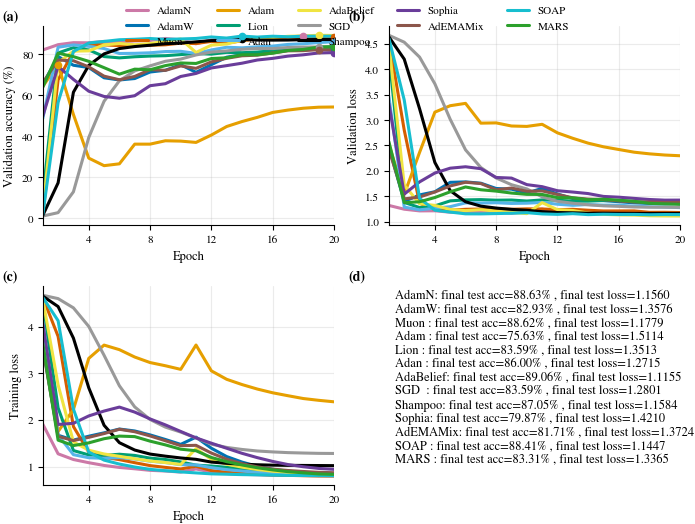

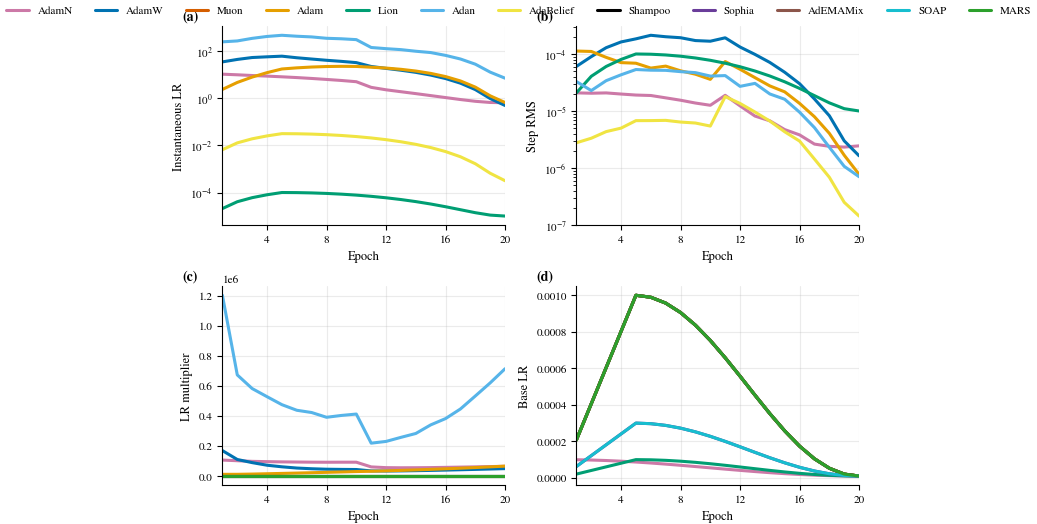

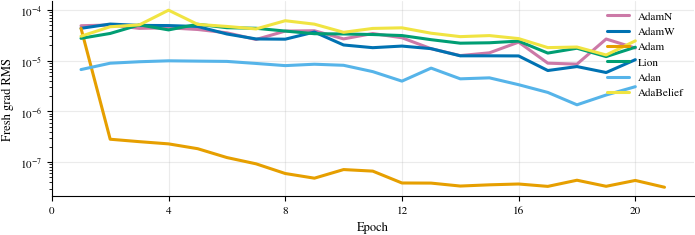

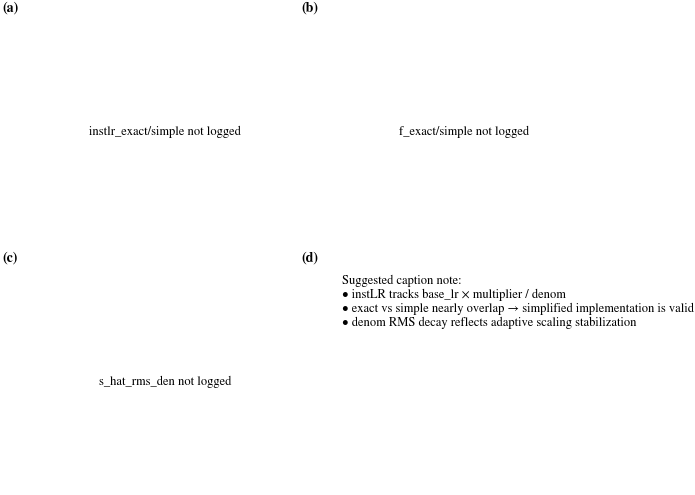

In [ ]:
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --------------------------
# 1) Publication style
# --------------------------
def set_paper_style(two_column=True, base_font=None):
    # single column ~ 3.35 in, double column ~ 7.0 in
    if base_font is None:
        base_font = 9 if two_column else 8

    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        "font.size": base_font,
        "axes.labelsize": base_font,
        "axes.titlesize": base_font,
        "xtick.labelsize": base_font - 1,
        "ytick.labelsize": base_font - 1,

        "lines.linewidth": 2.2,
        "lines.solid_capstyle": "round",

        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,

        "legend.frameon": False,
        "legend.fontsize": base_font - 1,

        # vector-friendly fonts
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })

def panel_label(ax, s):
    ax.text(-0.14, 1.08, s, transform=ax.transAxes,
            fontsize=mpl.rcParams["axes.labelsize"] + 1,
            fontweight="bold", va="top")

def H(d):
    return d["history"] if isinstance(d, dict) and "history" in d else d

def arr(hist, key):
    x = hist.get(key, None)
    if x is None or x == []:
        return None
    return np.asarray(x, dtype=float)

def as_percent(x):
    if x is None: return None
    return x * 100.0 if np.nanmax(x) <= 1.01 else x

def epoch_axis(ax, n):
    ax.set_xlim(1, n)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

def save_all(fig, out_dir, fname):
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(out_dir, f"{fname}.pdf"))
    fig.savefig(os.path.join(out_dir, f"{fname}.svg"))
    fig.savefig(os.path.join(out_dir, f"{fname}.png"), dpi=600)

# --------------------------
# 2) Figure 1: Main results (Val Acc, Val Loss, Train Loss)
# --------------------------
def plot_main_results(results, colors, out_dir="figs", fname="fig1_main", two_column=True):
    set_paper_style(two_column=two_column)

    order = [k for k in ['AdamN', 'AdamW', 'Muon', 'Adam', 'Lion', 'Adan', 'AdaBelief', 'SGD','Shampoo', 'Sophia', 'AdEMAMix', 'SOAP', 'MARS'] if k in results]
    W = 7.0 if two_column else 3.35
    fig, axs = plt.subplots(2, 2, figsize=(W, 5.2 if two_column else 4.6), constrained_layout=True)

    ax_acc, ax_vloss = axs[0,0], axs[0,1]
    ax_tloss, ax_blank = axs[1,0], axs[1,1]

    handles = None

    # (a) Val Accuracy
    for name in order:
        h = H(results[name])
        y = as_percent(arr(h, "val_accuracy"))
        if y is None:
            continue
        ep = np.arange(1, len(y)+1)
        line, = ax_acc.plot(ep, y, color=colors.get(name), label=name)
        # mark best epoch
        be = int(np.nanargmax(y))
        ax_acc.plot(ep[be], y[be], marker="o", ms=4.5, color=colors.get(name), zorder=3)

    ax_acc.set_ylabel("Validation accuracy (%)")
    ax_acc.set_xlabel("Epoch")
    panel_label(ax_acc, "(a)")
    epoch_axis(ax_acc, max(len(as_percent(arr(H(results[order[0]]), "val_accuracy"))), 1))

    # (b) Val Loss
    for name in order:
        h = H(results[name])
        y = arr(h, "val_loss")
        if y is None:
            continue
        ep = np.arange(1, len(y)+1)
        ax_vloss.plot(ep, y, color=colors.get(name), label=name)
    ax_vloss.set_ylabel("Validation loss")
    ax_vloss.set_xlabel("Epoch")
    panel_label(ax_vloss, "(b)")
    if order:
        any_hist = H(results[order[0]])
        n = len(arr(any_hist, "val_loss")) if arr(any_hist, "val_loss") is not None else 1
        epoch_axis(ax_vloss, max(n, 1))

    # (c) Train Loss
    for name in order:
        h = H(results[name])
        y = arr(h, "train_loss")
        if y is None:
            continue
        ep = np.arange(1, len(y)+1)
        ax_tloss.plot(ep, y, color=colors.get(name), label=name)
    ax_tloss.set_ylabel("Training loss")
    ax_tloss.set_xlabel("Epoch")
    panel_label(ax_tloss, "(c)")
    if order:
        any_hist = H(results[order[0]])
        n = len(arr(any_hist, "train_loss")) if arr(any_hist, "train_loss") is not None else 1
        epoch_axis(ax_tloss, max(n, 1))

    # (d) Put final test acc/loss as a small text panel instead of an empty plot
    ax_blank.axis("off")
    panel_label(ax_blank, "(d)")
    lines = []
    for name in order:
        h = H(results[name])
        fta = h.get("final_test_acc", None)
        ftl = h.get("final_test_loss", None)
        if fta is not None or ftl is not None:
            if fta is not None and fta <= 1.01: fta = fta*100
            lines.append(f"{name:5s}: final test acc={fta:.2f}% , final test loss={ftl:.4f}")
    ax_blank.text(0.02, 0.98, "\n".join(lines) if lines else "Final test metrics not available",
                  va="top", fontsize=mpl.rcParams["font.size"])

    # shared legend (top center)
    handles, labels = ax_acc.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=min(5, len(labels)), loc="upper center",
                   bbox_to_anchor=(0.5, 1.02))

    save_all(fig, out_dir, fname)
    plt.show()

# --------------------------
# 3) Figure 2: Dynamics (inst_lr, step_rms, multiplier, base_lr)
# --------------------------
def plot_optimizer_dynamics(results, colors, out_dir="figs", fname="fig2_dynamics", two_column=True):
    set_paper_style(two_column=two_column)

    # SGD doesn't have these keys; include only those present
    order = [k for k in ['AdamN', 'AdamW', 'Muon', 'Adam', 'Lion', 'Adan', 'AdaBelief', 'Shampoo', 'Sophia', 'AdEMAMix', 'SOAP', 'MARS'] if k in results]
    W = 7.0 if two_column else 3.35
    fig, axs = plt.subplots(2, 2, figsize=(W, 5.2 if two_column else 4.6), constrained_layout=True)

    ax_lr, ax_step = axs[0,0], axs[0,1]
    ax_mult, ax_base = axs[1,0], axs[1,1]

    # (a) inst_lr (log-scale helps comparison)
    used = False
    for name in order:
        h = H(results[name])
        y = arr(h, "inst_lr")
        if y is None: continue
        ep = np.arange(1, len(y)+1)
        ax_lr.plot(ep, y, color=colors.get(name), label=name)
        used = True
    ax_lr.set_ylabel("Instantaneous LR")
    ax_lr.set_xlabel("Epoch")
    ax_lr.set_yscale("log")
    panel_label(ax_lr, "(a)")
    if used:
        epoch_axis(ax_lr, len(arr(H(results[order[0]]), "inst_lr")))
    else:
        ax_lr.text(0.5, 0.5, "inst_lr not logged", ha="center", va="center", transform=ax_lr.transAxes)

    # (b) step_rms (log)
    used = False
    for name in order:
        h = H(results[name])
        y = arr(h, "step_rms")
        if y is None: continue
        ep = np.arange(1, len(y)+1)
        ax_step.plot(ep, y, color=colors.get(name), label=name)
        used = True
    ax_step.set_ylabel("Step RMS")
    ax_step.set_xlabel("Epoch")
    ax_step.set_yscale("log")
    panel_label(ax_step, "(b)")
    if used:
        epoch_axis(ax_step, len(arr(H(results[order[0]]), "step_rms")))

    # (c) multiplier
    used = False
    for name in order:
        h = H(results[name])
        y = arr(h, "multiplier")
        if y is None: continue
        ep = np.arange(1, len(y)+1)
        ax_mult.plot(ep, y, color=colors.get(name), label=name)
        used = True
    ax_mult.set_ylabel("LR multiplier")
    ax_mult.set_xlabel("Epoch")
    panel_label(ax_mult, "(c)")
    if used:
        epoch_axis(ax_mult, len(arr(H(results[order[0]]), "multiplier")))

    # (d) base_lr (linear)
    used = False
    for name in order:
        h = H(results[name])
        y = arr(h, "base_lr")
        if y is None: continue
        ep = np.arange(1, len(y)+1)
        ax_base.plot(ep, y, color=colors.get(name), label=name)
        used = True
    ax_base.set_ylabel("Base LR")
    ax_base.set_xlabel("Epoch")
    panel_label(ax_base, "(d)")
    if used:
        epoch_axis(ax_base, len(arr(H(results[order[0]]), "base_lr")))

    handles, labels = ax_lr.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=len(labels), loc="upper center",
                   bbox_to_anchor=(0.5, 1.02))

    save_all(fig, out_dir, fname)
    plt.show()

# --------------------------
# 4) Figure 3: Fresh grad RMS (log) — only for optimizers that logged it
# --------------------------
def plot_fresh_grad(results, colors, out_dir="figs", fname="fig3_fresh_grad", two_column=True):
    set_paper_style(two_column=two_column)

    order = [k for k in ['AdamN', 'AdamW', 'Muon', 'Adam', 'Lion', 'Adan', 'AdaBelief','Shampoo', 'Sophia', 'AdEMAMix', 'SOAP', 'MARS'] if k in results and arr(H(results[k]), "fresh_grad_rms") is not None]
    W = 7.0 if two_column else 3.35
    fig, ax = plt.subplots(1, 1, figsize=(W, 2.4), constrained_layout=True)

    for name in order:
        h = H(results[name])
        y = arr(h, "fresh_grad_rms")
        ep = np.arange(1, len(y)+1)
        ax.plot(ep, y, color=colors.get(name), label=name)

    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Fresh grad RMS")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.legend(loc="upper right")

    save_all(fig, out_dir, fname)
    plt.show()

# --------------------------
# 5) Figure 4: AdamN-only diagnostics
#    instlr_exact vs instlr_simple, f_exact vs f_simple, s_hat_rms_den (log)
# --------------------------
def plot_adamn_diagnostics(results, out_dir="figs", fname="fig4_adamn_diag", two_column=True):
    set_paper_style(two_column=two_column)

    an = results.get("AdamN", None)
    if an is None:
        print("[info] AdamN not found.")
        return
    h = H(an)

    inst_e = arr(h, "instlr_exact")
    inst_s = arr(h, "instlr_simple")
    f_e    = arr(h, "f_exact")
    f_s    = arr(h, "f_simple")
    den    = arr(h, "s_hat_rms_den")

    W = 7.0 if two_column else 3.35
    fig, axs = plt.subplots(2, 2, figsize=(W, 5.0 if two_column else 4.4), constrained_layout=True)

    # (a) instlr exact vs simple (log)
    ax = axs[0,0]
    if inst_e is not None and inst_s is not None:
        ep = np.arange(1, len(inst_e)+1)
        ax.plot(ep, inst_e, label="instLR (exact)")
        ax.plot(ep, inst_s, label="instLR (simple)", linestyle="--")
        ax.set_yscale("log")
        ax.set_ylabel("Instantaneous LR")
        ax.set_xlabel("Epoch")
        ax.legend(loc="upper right")
        epoch_axis(ax, len(inst_e))
    else:
        ax.text(0.5, 0.5, "instlr_exact/simple not logged", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    panel_label(axs[0,0], "(a)")

    # (b) f_exact vs f_simple
    ax = axs[0,1]
    if f_e is not None and f_s is not None:
        ep = np.arange(1, len(f_e)+1)
        ax.plot(ep, f_e, label="f_exact")
        ax.plot(ep, f_s, label="f_simple", linestyle="--")
        ax.set_ylabel("Freshness factor f")
        ax.set_xlabel("Epoch")
        ax.legend(loc="upper right")
        epoch_axis(ax, len(f_e))
    else:
        ax.text(0.5, 0.5, "f_exact/simple not logged", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    panel_label(axs[0,1], "(b)")

    # (c) denominator RMS (log)
    ax = axs[1,0]
    if den is not None:
        ep = np.arange(1, len(den)+1)
        ax.plot(ep, den, label=r"RMS($\sqrt{\hat{s}_t}$)")
        ax.set_yscale("log")
        ax.set_ylabel("Denom RMS")
        ax.set_xlabel("Epoch")
        ax.legend(loc="upper right")
        epoch_axis(ax, len(den))
    else:
        ax.text(0.5, 0.5, "s_hat_rms_den not logged", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    panel_label(axs[1,0], "(c)")

    # (d) show relationship note
    ax = axs[1,1]
    ax.axis("off")
    panel_label(ax, "(d)")
    ax.text(0.02, 0.98,
            "Suggested caption note:\n"
            "• instLR tracks base_lr × multiplier / denom\n"
            "• exact vs simple nearly overlap → simplified implementation is valid\n"
            "• denom RMS decay reflects adaptive scaling stabilization",
            va="top", fontsize=mpl.rcParams["font.size"])

    save_all(fig, out_dir, fname)
    plt.show()

# ==========================
# RUN (generate the paper figures)
# ==========================
plot_main_results(results, colors, out_dir="figs", fname="fig1_main", two_column=True)
plot_optimizer_dynamics(results, colors, out_dir="figs", fname="fig2_dynamics", two_column=True)
plot_fresh_grad(results, colors, out_dir="figs", fname="fig3_fresh_grad", two_column=True)
plot_adamn_diagnostics(results, out_dir="figs", fname="fig4_adamn_diag", two_column=True)


In [ ]:
def plot_main_results(results, colors, out_dir="figs", fname="fig1_main",
                      two_column=True,
                      baseline="AdamW",
                      milestones=(10,20,50),
                      early_range=(1, 30),
                      late_range=(70, 100),
                      inset_size=("52%","52%"),
                      dpi_screen=150):
    set_paper_style(two_column=two_column)

    order = [k for k in ['AdamN', 'AdamW', 'Muon', 'Adam', 'Lion', 'Adan', 'AdaBelief','Shampoo', 'Sophia', 'AdEMAMix', 'SOAP', 'MARS'] if k in results]

    # Bigger on-screen figure.
    W = 7.4 if two_column else 4.2
    Hh = 5.6 if two_column else 5.2
    fig, axs = plt.subplots(2, 2, figsize=(W, Hh))
    fig.set_dpi(dpi_screen)


    plt.subplots_adjust(top=0.88, wspace=0.28, hspace=0.35)

    ax_acc, ax_vloss = axs[0,0], axs[0,1]
    ax_tloss, ax_info = axs[1,0], axs[1,1]

    # -------- (a) Val Accuracy --------
    acc_cache = {}
    max_ep = 0

    for name in order:
        h = H(results[name])
        y = as_percent(arr(h, "val_accuracy"))
        if y is None:
            continue
        acc_cache[name] = y
        max_ep = max(max_ep, len(y))
        ep = np.arange(1, len(y)+1)

        ax_acc.plot(ep, y, color=colors.get(name), label=name)

        # mark best epoch
        be = int(np.nanargmax(y))
        ax_acc.plot(ep[be], y[be], marker="o", ms=4.5, color=colors.get(name), zorder=3)

    ax_acc.set_ylabel("Validation accuracy (%)")
    ax_acc.set_xlabel("Epoch")
    panel_label(ax_acc, "(a)")
    if max_ep > 0:
        epoch_axis(ax_acc, max_ep)

    # Helper: tight y-lims within a window (so zoom actually zooms)
    def window_ylim(x1, x2):
        ys = []
        for y in acc_cache.values():
            if len(y) >= x1:
                ys.append(y[x1-1:min(x2, len(y))])
        if not ys:
            return None
        y_all = np.concatenate(ys)
        y_min, y_max = float(np.nanmin(y_all)), float(np.nanmax(y_all))
        pad = 0.03 * max(1e-6, (y_max - y_min))
        return (y_min - pad, y_max + pad)

    # -------- Early inset: EXACT epochs 1–15 --------
    if acc_cache and max_ep >= early_range[1]:
        e1, e2 = early_range
        e1 = max(1, int(e1))
        e2 = min(max_ep, int(e2))

        lims = window_ylim(e1, e2)
        if lims is not None:
            axins1 = inset_axes(ax_acc, width=inset_size[0], height=inset_size[1],
                                loc="lower left", borderpad=1.0)
            for name, y in acc_cache.items():
                ep = np.arange(1, len(y)+1)
                axins1.plot(ep, y, color=colors.get(name))
            axins1.set_xlim(e1, e2)
            axins1.set_ylim(*lims)
            axins1.grid(True, alpha=0.20)
            axins1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
            axins1.set_xticks([1, 5, 10, 15])
            axins1.tick_params(labelsize=mpl.rcParams["xtick.labelsize"] - 1)

            mark_inset(ax_acc, axins1, loc1=1, loc2=3, fc="none", ec="0.35", lw=0.8)

    # -------- Late inset: EXACT epochs 70–100 --------
    if acc_cache and max_ep >= late_range[0]:
        l1, l2 = late_range
        l1 = max(1, int(l1))
        l2 = min(max_ep, int(l2))

        lims = window_ylim(l1, l2)
        if lims is not None:
            axins2 = inset_axes(ax_acc, width=inset_size[0], height=inset_size[1],
                                loc="lower right", borderpad=1.0)
            for name, y in acc_cache.items():
                ep = np.arange(1, len(y)+1)
                axins2.plot(ep, y, color=colors.get(name))
            axins2.set_xlim(l1, l2)
            axins2.set_ylim(*lims)
            axins2.grid(True, alpha=0.20)
            axins2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
            axins2.set_xticks([70, 80, 90, 100])
            axins2.tick_params(labelsize=mpl.rcParams["xtick.labelsize"] - 1)

            mark_inset(ax_acc, axins2, loc1=2, loc2=4, fc="none", ec="0.35", lw=0.8)

    # -------- (b) Val Loss --------
    n_v = 0
    for name in order:
        h = H(results[name])
        y = arr(h, "val_loss")
        if y is None:
            continue
        ep = np.arange(1, len(y)+1)
        ax_vloss.plot(ep, y, color=colors.get(name))
        n_v = max(n_v, len(y))
    ax_vloss.set_ylabel("Validation loss")
    ax_vloss.set_xlabel("Epoch")
    panel_label(ax_vloss, "(b)")
    if n_v > 0:
        epoch_axis(ax_vloss, n_v)

    # -------- (c) Train Loss --------
    n_t = 0
    for name in order:
        h = H(results[name])
        y = arr(h, "train_loss")
        if y is None:
            continue
        ep = np.arange(1, len(y)+1)
        ax_tloss.plot(ep, y, color=colors.get(name))
        n_t = max(n_t, len(y))
    ax_tloss.set_ylabel("Training loss")
    ax_tloss.set_xlabel("Epoch")
    panel_label(ax_tloss, "(c)")
    if n_t > 0:
        epoch_axis(ax_tloss, n_t)

    # -------- (d) Info panel  --------
    ax_info.axis("off")
    panel_label(ax_info, "(d)")

    info_lines = []
    if baseline in acc_cache:
        base_curve = acc_cache[baseline]

        def pick(curve, e):
            e = min(max(1, int(e)), len(curve))
            return float(curve[e-1])

        ms = list(milestones)
        if max_ep > 0 and (max_ep not in ms):
            ms.append(max_ep)

        header = f"Val acc @ epochs (Δ vs {baseline})"
        info_lines += [header, "-"*len(header)]
        for name in order:
            if name not in acc_cache:
                continue
            cur = acc_cache[name]
            row = [f"{name:6s}"]
            for e in ms:
                a = pick(cur, e); b = pick(base_curve, e)
                row.append(f"e{e:>3d}: {a:5.2f}% ({a-b:+.2f})")
            info_lines.append(" | ".join(row))
    else:
        info_lines.append(f"Baseline '{baseline}' not available.")

    info_lines += ["", "Final test metrics", "------------------"]
    for name in order:
        h = H(results[name])
        fta = h.get("final_test_acc", None)
        ftl = h.get("final_test_loss", None)
        if fta is None and ftl is None:
            continue
        if fta is not None and fta <= 1.01:
            fta *= 100
        info_lines.append(f"{name:6s}: acc={fta:.2f}% , loss={ftl:.4f}")

    ax_info.text(0.02, 0.98, "\n".join(info_lines),
                 va="top", fontsize=mpl.rcParams["font.size"]-1)

    # Shared legend (top center)
    handles, labels = ax_acc.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=min(5, len(labels)),
                   loc="upper center", bbox_to_anchor=(0.5, 0.98))

    save_all(fig, out_dir, fname)
    plt.show()


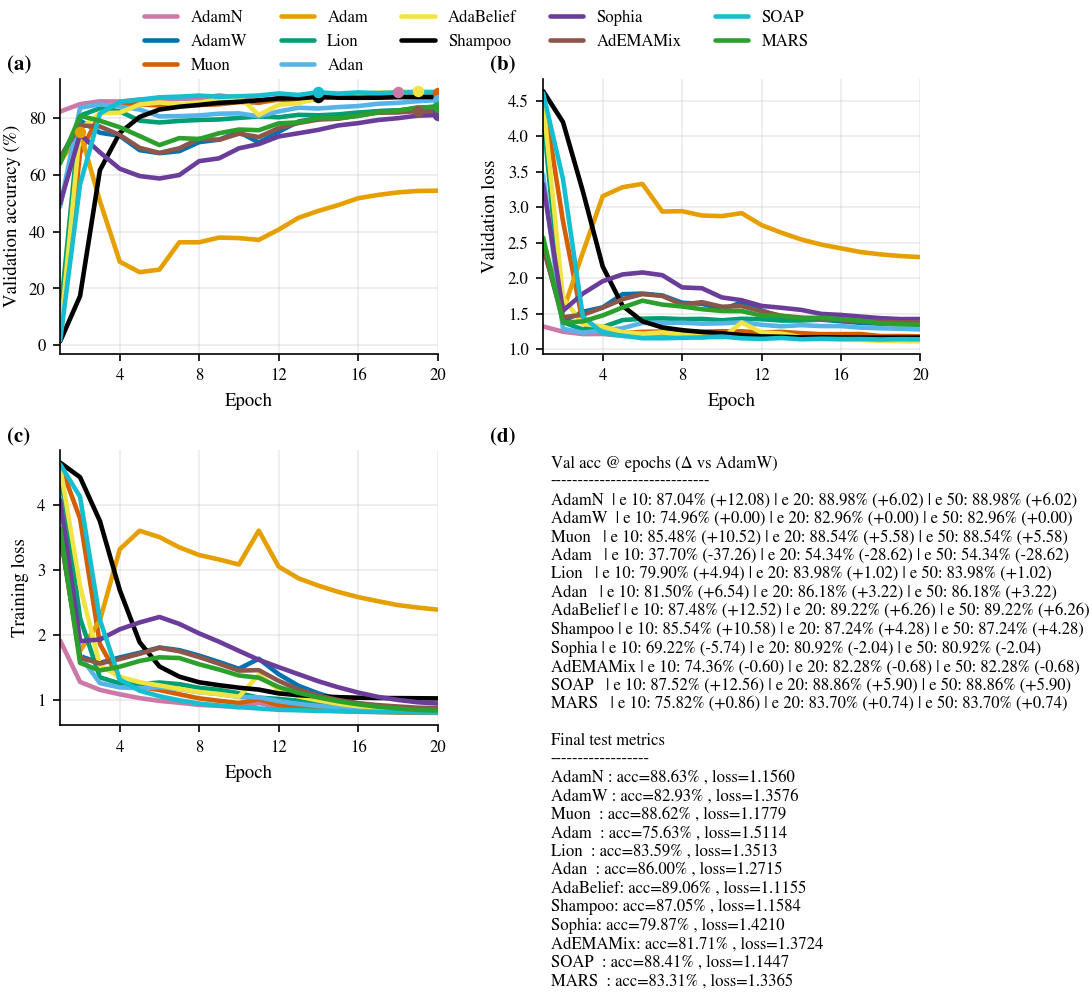

In [ ]:
plot_main_results(
    results, colors,
    out_dir="figs",
    fname="fig1_main_two_insets_exact_ranges",
    two_column=True,
    early_range=(1, 30),
    late_range=(70, 100),
    inset_size=("30%","30%")  # if we want them even bigger
)
